# Optimising a Support Vector Machine (SVM) Classifier

In this notebook, we demonstrate how to **tune hyperparameters** in a Support Vector Machine (SVM) classifier to improve classification performance.

We will use the **Breast Cancer Wisconsin dataset** to:
- Train an initial SVM model.
- Explore the effects of the most important hyperparameters:
  - `C` — Regularization parameter controlling the trade-off between achieving low training error and low testing error.
  - `gamma` — Kernel coefficient controlling how much influence each data point has on the decision boundary.
  - `kernel` — Defines the type of decision boundary (linear or nonlinear), with options like `'linear'`, `'rbf'`, and `'poly'`.

Support Vector Machines are powerful models for classification tasks and can handle both linear and non-linear relationships through the use of kernel functions. By tuning these hyperparameters, we can significantly improve model performance.


## Step 1: Load Breast Cancer Data

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Exploring the Effect of the `C` Hyperparameter

The `C` parameter in SVM controls the **regularization strength**:
- **Low `C` values** → More regularization → Smoother decision boundary, possibly underfitting.
- **High `C` values** → Less regularization → Fits the training data more closely, potentially overfitting.

We will train SVM models with different `C` values and observe how it affects accuracy.


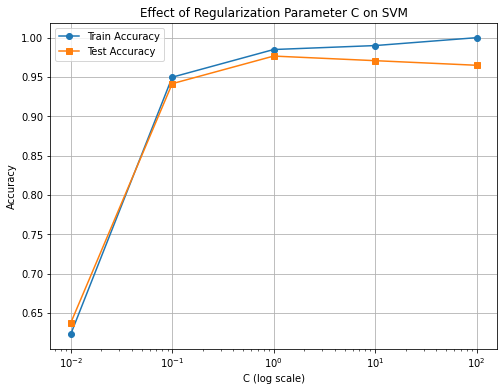

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Test different values of C
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for C in C_values:
    model = SVC(C=C, kernel='rbf', gamma='scale')
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Plot the results
plt.figure(figsize=(8, 6))
plt.semilogx(C_values, train_scores, marker='o', label='Train Accuracy')
plt.semilogx(C_values, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization Parameter C on SVM')
plt.legend()
plt.grid(True)
plt.show()


## Exploring the Effect of the `gamma` Hyperparameter

The `gamma` parameter controls the **influence of each individual training example**:
- **Low `gamma` values** → Far-reaching influence → Smoother decision boundary, possibly underfitting.
- **High `gamma` values** → Very localized influence → Complex decision boundary, potentially overfitting.

We will now examine how varying `gamma` affects the model’s performance, while keeping `C` fixed.


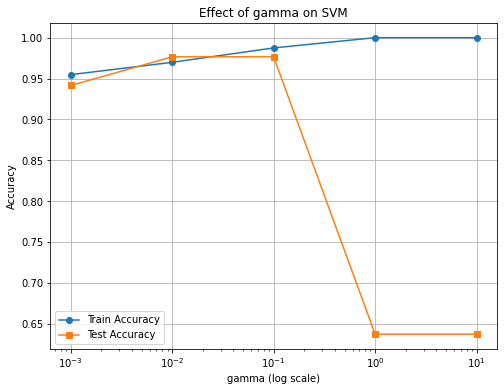

In [3]:
# Test different values of gamma
gamma_values = [0.001, 0.01, 0.1, 1, 10]
train_scores = []
test_scores = []

for gamma in gamma_values:
    model = SVC(C=1, kernel='rbf', gamma=gamma)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Plot the results
plt.figure(figsize=(8, 6))
plt.semilogx(gamma_values, train_scores, marker='o', label='Train Accuracy')
plt.semilogx(gamma_values, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('gamma (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of gamma on SVM')
plt.legend()
plt.grid(True)
plt.show()


## Exploring the Effect of the `kernel` Hyperparameter

The `kernel` parameter in SVM specifies the **type of transformation** applied to the input data:
- `'linear'` → No transformation; linear decision boundary.
- `'rbf'` (Radial Basis Function) → Maps data into higher dimensions for non-linear boundaries.
- `'poly'` → Polynomial transformations, allowing more flexible decision boundaries depending on degree.

We will now compare different kern


Kernel: linear → Train Accuracy: 0.987, Test Accuracy: 0.988
Kernel: rbf → Train Accuracy: 0.985, Test Accuracy: 0.977
Kernel: poly → Train Accuracy: 0.910, Test Accuracy: 0.883


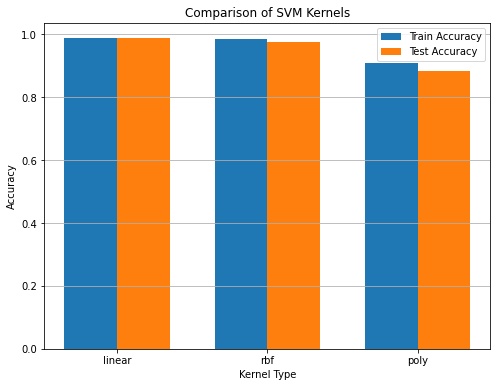

In [4]:
# Test different kernel types
kernel_types = ['linear', 'rbf', 'poly']
train_scores = []
test_scores = []

for kernel in kernel_types:
    model = SVC(C=1, kernel=kernel, gamma='scale')
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Show numeric results
for k, tr, te in zip(kernel_types, train_scores, test_scores):
    print(f"Kernel: {k} → Train Accuracy: {tr:.3f}, Test Accuracy: {te:.3f}")

# Plot the results
import numpy as np

x = np.arange(len(kernel_types))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, train_scores, width, label='Train Accuracy')
plt.bar(x + width/2, test_scores, width, label='Test Accuracy')
plt.xticks(x, kernel_types)
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy')
plt.title('Comparison of SVM Kernels')
plt.legend()
plt.grid(True, axis='y')
plt.show()


## Changing the Classification Threshold

Most classifiers output probabilities between 0 and 1.
By default, the threshold for classification is 0.5. This means:

- If predicted probability ≥ 0.5 → classify as **positive**
- Else → classify as **negative**

### Changing the Threshold:
- **Lower threshold** → more positives predicted → higher **recall**, more **false positives**
- **Higher threshold** → fewer positives predicted → higher **precision**, more **false negatives**

Choosing the right threshold depends on your application's goals.

We'll now visualize how the confusion matrix changes for **two different thresholds**.

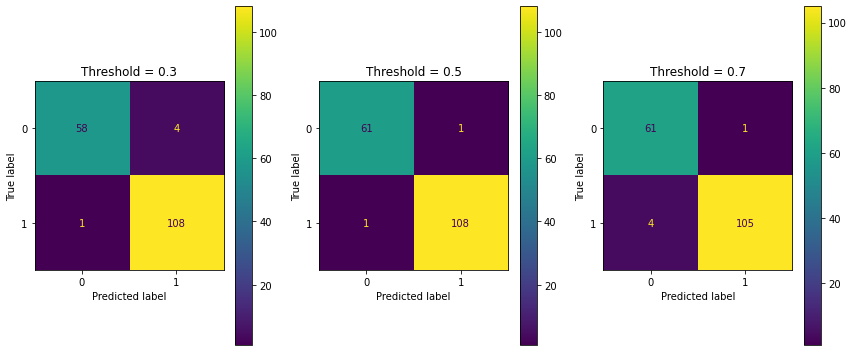

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = [0.3, 0.5, 0.7]         # List of two thresholds to compare


# Train SVM with probability estimates enabled
model = SVC(C=1, kernel='rbf', gamma='scale', probability=True)
model.fit(X_train, y_train)

# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1


# Plot side-by-side confusion matrices
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
for i, thresh in enumerate(thresholds):
    y_pred = (y_proba >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[i])
    axs[i].set_title(f"Threshold = {thresh}")
plt.tight_layout()
plt.show()
